In [34]:
import pandas as pd
import os
from sqlalchemy import create_engine, text
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (15, 6)
sns.set_style('darkgrid')

In [20]:
DB_HOST = os.getenv("DB_HOST", "db")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "weather_db")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "postgres")

DATABASE_URL = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [21]:
engine = create_engine(DATABASE_URL)

In [22]:
with engine.connect() as conn:
    loc_df = pd.read_sql("select * from location", conn)
    weather_df = pd.read_sql("select * from weather_observation", conn)

In [23]:
weather_df.head()

,id,location_id,observed_at,temperature,feels_like,humidity,pressure,wind_speed,weather_description,weather_code,raw_json,created_at
0,7cc67643-b3cc-4dba-9a33-d7d3f86bd1b5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 04:00:00+00:00,4.2,2.0,93.0,1001.0,4.2,None,3,None,2026-05-15 17:26:11.758867+00:00
1,ed70cecd-72f7-4fcc-a9f1-18e0533a5b66,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 05:00:00+00:00,4.2,1.9,93.0,1001.5,5.4,None,3,None,2026-05-15 17:26:11.758867+00:00
2,4b178fa5-df7b-481b-9a03-1242275c67d5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 06:00:00+00:00,4.2,1.8,96.0,1001.7,6.5,None,51,None,2026-05-15 17:26:11.758867+00:00
3,d7977da2-6fb4-4df1-ad28-b86d57054e1a,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 07:00:00+00:00,4.4,2.2,96.0,1001.7,5.2,None,55,None,2026-05-15 17:26:11.758867+00:00
4,318e0712-f3e4-4964-89bc-da25576eed64,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 08:00:00+00:00,4.4,2.0,95.0,1001.8,6.4,None,51,None,2026-05-15 17:26:11.758867+00:00


In [24]:
df = loc_df.merge(weather_df, left_on='id', right_on='location_id', suffixes=['_loc', '_wea'])

In [25]:
seattle = df[df['city'] == 'Seattle']

In [26]:
seattle.shape

(2880, 19)

In [27]:
seattle.head()

,id_loc,city,state,country,latitude,longitude,created_at_loc,id_wea,location_id,observed_at,temperature,feels_like,humidity,pressure,wind_speed,weather_description,weather_code,raw_json,created_at_wea
0,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,7cc67643-b3cc-4dba-9a33-d7d3f86bd1b5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 04:00:00+00:00,4.2,2.0,93.0,1001.0,4.2,None,3,None,2026-05-15 17:26:11.758867+00:00
1,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,ed70cecd-72f7-4fcc-a9f1-18e0533a5b66,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 05:00:00+00:00,4.2,1.9,93.0,1001.5,5.4,None,3,None,2026-05-15 17:26:11.758867+00:00
2,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,4b178fa5-df7b-481b-9a03-1242275c67d5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 06:00:00+00:00,4.2,1.8,96.0,1001.7,6.5,None,51,None,2026-05-15 17:26:11.758867+00:00
3,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,d7977da2-6fb4-4df1-ad28-b86d57054e1a,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 07:00:00+00:00,4.4,2.2,96.0,1001.7,5.2,None,55,None,2026-05-15 17:26:11.758867+00:00
4,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,318e0712-f3e4-4964-89bc-da25576eed64,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 08:00:00+00:00,4.4,2.0,95.0,1001.8,6.4,None,51,None,2026-05-15 17:26:11.758867+00:00


In [28]:
seattle['observed_date'] = seattle['observed_at'].dt.strftime('%Y-%m-%d')

In [29]:
seattle.groupby("observed_date")[['temperature', 'feels_like']].mean()

,temperature,feels_like
observed_date,,
2026-01-01,2.495833,0.233333
2026-01-02,5.095833,3.208333
2026-01-03,8.145833,6.320833
2026-01-04,8.191667,5.745833
2026-01-05,5.829167,3.487500
...,...,...
2026-04-26,11.537500,9.012500
2026-04-27,11.679167,9.212500
2026-04-28,10.283333,8.095833


In [30]:
seattle['month'] = seattle['observed_at'].dt.month_name()

In [31]:
seattle_jan = seattle[seattle['month'] == 'January']

In [32]:
seattle_jan.head()

,id_loc,city,state,country,latitude,longitude,created_at_loc,id_wea,location_id,observed_at,...,feels_like,humidity,pressure,wind_speed,weather_description,weather_code,raw_json,created_at_wea,observed_date,month
0,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,7cc67643-b3cc-4dba-9a33-d7d3f86bd1b5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 04:00:00+00:00,...,2.0,93.0,1001.0,4.2,None,3,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January
1,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,ed70cecd-72f7-4fcc-a9f1-18e0533a5b66,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 05:00:00+00:00,...,1.9,93.0,1001.5,5.4,None,3,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January
2,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,4b178fa5-df7b-481b-9a03-1242275c67d5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 06:00:00+00:00,...,1.8,96.0,1001.7,6.5,None,51,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January
3,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,d7977da2-6fb4-4df1-ad28-b86d57054e1a,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 07:00:00+00:00,...,2.2,96.0,1001.7,5.2,None,55,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January
4,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,318e0712-f3e4-4964-89bc-da25576eed64,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 08:00:00+00:00,...,2.0,95.0,1001.8,6.4,None,51,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January


<Axes: xlabel='observed_at', ylabel='temperature'>

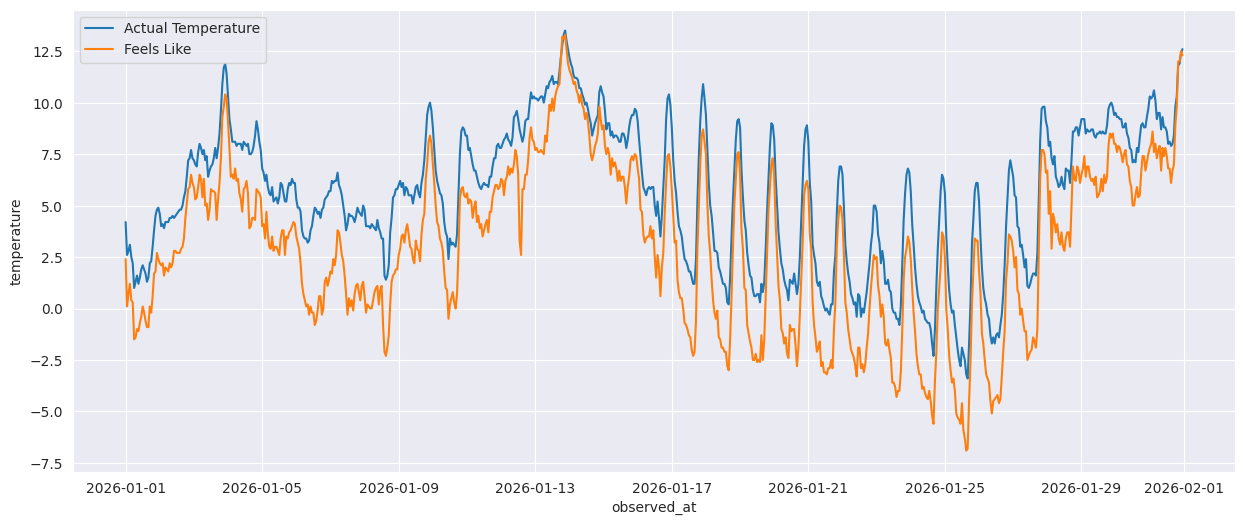

In [35]:
sns.lineplot(data=seattle_jan, x='observed_at', y='temperature', label='Actual Temperature')
sns.lineplot(data=seattle_jan, x='observed_at', y='feels_like', label='Feels Like')

In [36]:
def to_f(temp):
    return (temp * (9/5)) + 32

In [39]:
seattle_jan['temperature_f'] = seattle_jan['temperature'].apply(to_f)
seattle_jan['feels_like_f'] = seattle_jan['feels_like'].apply(to_f)

<Axes: xlabel='observed_at', ylabel='temperature_f'>

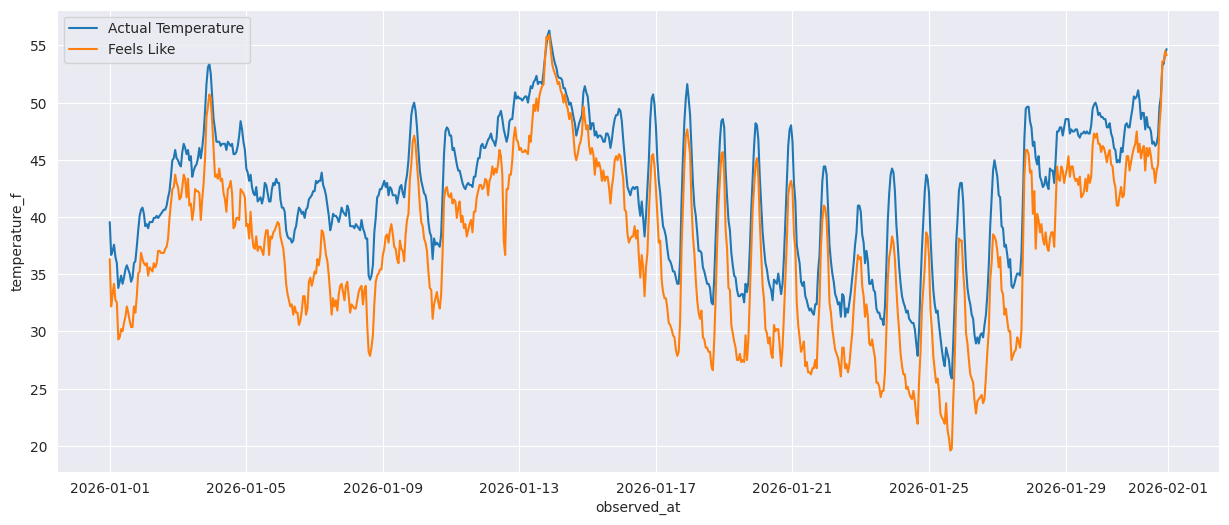

In [40]:
sns.lineplot(data=seattle_jan, x='observed_at', y='temperature_f', label='Actual Temperature')
sns.lineplot(data=seattle_jan, x='observed_at', y='feels_like_f', label='Feels Like')

In [60]:
seattle_jan_group = seattle_jan.groupby(['observed_date'])[['temperature', 'temperature_f', 'feels_like', 'feels_like_f', 'wind_speed']].mean().reset_index()

In [61]:
seattle_jan_group

,observed_date,temperature,temperature_f,feels_like,feels_like_f,wind_speed
0,2026-01-01,2.495833,36.4925,0.233333,32.4200,3.216667
1,2026-01-02,5.095833,41.1725,3.208333,37.7750,3.654167
2,2026-01-03,8.145833,46.6625,6.320833,43.3775,6.466667
3,2026-01-04,8.191667,46.7450,5.745833,42.3425,10.254167
4,2026-01-05,5.829167,42.4925,3.487500,38.2775,7.137500
5,2026-01-06,4.487500,40.0775,0.770833,33.3875,14.133333
6,2026-01-07,5.087500,41.1575,1.487500,34.6775,13.862500
7,2026-01-08,3.854167,38.9375,0.266667,32.4800,12.487500
8,2026-01-09,6.595833,43.8725,4.141667,39.4550,7.816667
9,2026-01-10,5.508333,41.9150,3.000000,37.4000,5.529167


In [69]:
seattle_jan_group['diff_t'] = seattle_jan_group['temperature_f'] - seattle_jan_group['feels_like_f']
seattle_jan_group['diff'] = seattle_jan_group['temperature'] - seattle_jan_group['feels_like']

In [62]:
seattle_jan_group['observed_date'] = pd.to_datetime(seattle_jan_group['observed_date'])

<Axes: xlabel='observed_date', ylabel='temperature_f'>

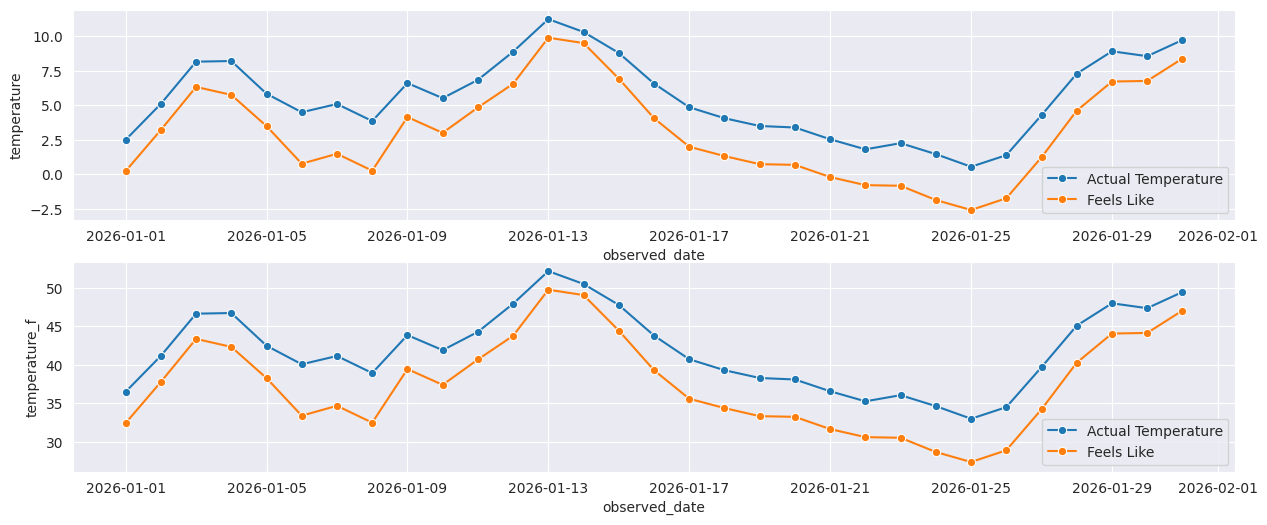

In [70]:
fig, ax = plt.subplots(2, 1)
sns.lineplot(data=seattle_jan_group, x='observed_date', y='temperature', label='Actual Temperature', marker='o', ax=ax[0])
sns.lineplot(data=seattle_jan_group, x='observed_date', y='feels_like', label='Feels Like', marker='o', ax=ax[0])

sns.lineplot(data=seattle_jan_group, x='observed_date', y='temperature_f', label='Actual Temperature', marker='o', ax=ax[1])
sns.lineplot(data=seattle_jan_group, x='observed_date', y='feels_like_f', label='Feels Like', marker='o', ax=ax[1])

In [64]:
seattle_jan['observed_date'] = pd.to_datetime(seattle_jan['observed_date'])

In [ ]:
seattle_jan.dtypes

<Axes: xlabel='observed_date', ylabel='wind_speed'>

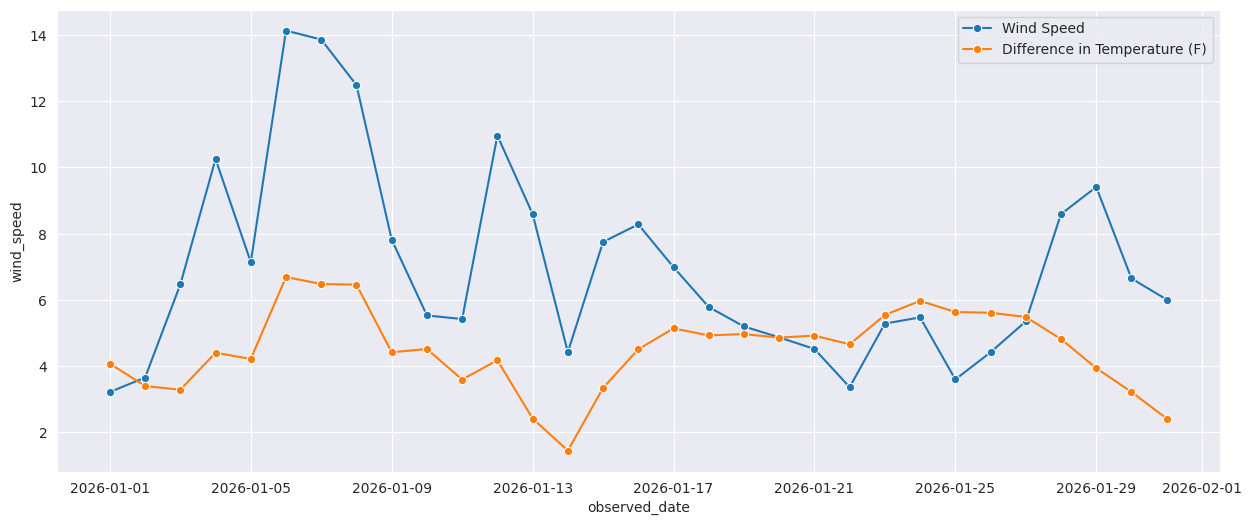

In [74]:
sns.lineplot(data=seattle_jan_group, x='observed_date', y='wind_speed', marker='o', label='Wind Speed')

sns.lineplot(data=seattle_jan_group, x='observed_date', y='diff_t', marker='o', label='Difference in Temperature (F)')